In [1]:
# Detecting compatibility of scipy and quimb versions
import scipy
import quimb
print(scipy.__version__)
print(quimb.__version__)

%config InlineBackend.figure_formats = ['svg']

import quimb as qu
import quimb.tensor as qtn

1.15.2
1.11.2


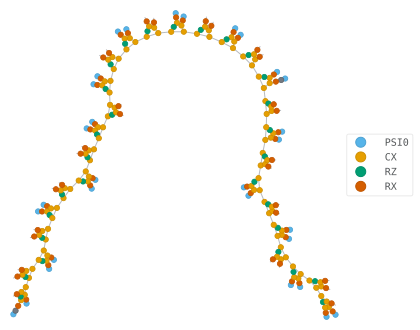

0.015777783068614715 0.001597761791104102


<Circuit(n=30, num_gates=149, gate_opts={'contract': 'auto-split-gate', 'propagate_tags': 'register'})>

In [4]:
import numpy as np
# I found that this random generator needs "numpy version >=2.0" to work properly
seed = 43
np.random.seed(seed)

# 20 qubits and tag the initial wavefunction tensors
N = 30
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间
r = 1   # trotter步数

z_angle = - J * t / r
x_angle = - h * t / r

# coefficient \lambda
single_qubit_noise = np.log(- 0.002 * 2 + 1) * (-0.5) # * np.ones(N)
two_qubit_noise = np.log(- 0.0002 * 2 + 1) * (-0.5) # * np.ones(N-1)

noise_level = 8

# probabilities of error 1-\omega
w_1 = (1 - np.exp(- 2 * noise_level * single_qubit_noise) ) / 2
w_2 = (1 - np.exp(- 2 * noise_level * two_qubit_noise) ) / 2


circ = qtn.Circuit(N)

def sample_noise(circ, i, w_1):
    if np.random.rand() < w_1:
            circ.apply_gate('X', i)
    if np.random.rand() < w_1:
            circ.apply_gate('Y', i)
    if np.random.rand() < w_1:
            circ.apply_gate('Z', i)
            
def sample_Pauli_noise(circ, i, w_2):
    if np.random.rand() < w_2:
            circ.apply_gate('X', i)
            circ.apply_gate('X', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('X', i)
            circ.apply_gate('Y', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('X', i)
            circ.apply_gate('Z', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Y', i)
            circ.apply_gate('X', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Y', i)
            circ.apply_gate('Y', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Y', i)
            circ.apply_gate('Z', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Z', i)
            circ.apply_gate('X', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Z', i)
            circ.apply_gate('Y', i+1)
    if np.random.rand() < w_2:
            circ.apply_gate('Z', i)
            circ.apply_gate('Z', i+1)
        
# initial layer
for i in range(N):
    sample_noise(circ, i, w_1)
        
    circ.apply_gate('RX', x_angle, i) 

# 8 rounds of entangling gates
for j in range(1, r+1):

    # ZZ rotations on even pairs
    for i in range(0, N-1, 2):
        sample_Pauli_noise(circ, i, w_2)
            
        circ.apply_gate('CX', i, i + 1)
        circ.apply_gate('RZ', 2 * z_angle, i+1)
        circ.apply_gate('CX', i, i + 1)
        
    # ZZ rotations odd pairs
    for i in range(1, N-1, 2):
        sample_Pauli_noise(circ, i, w_2)
            
        circ.apply_gate('CX', i, i + 1)
        circ.apply_gate('RZ', 2 * z_angle, i+1) 
        circ.apply_gate('CX', i, i + 1)

    # X rotations
    if j < r:
        for i in range(N):
            sample_noise(circ, i, w_1)
            
            circ.apply_gate('RX', 2 * x_angle, i) # , gate_round=j)
    else:
        for i in range(N):
            sample_noise(circ, i, w_1)
             
            circ.apply_gate('RX', x_angle, i) # , gate_round=j+1)


# plot
circ.psi.draw(color=['PSI0', 'CX', 'RZ', 'RX'])

if 0:
    for g in circ.gates:
        print(g)
        
print(w_1, w_2)
circ

In [ ]:
%%time
from pathlib import Path
import json

# collect the 8 samples (seeded for reproducibility)
samples = list(circ.sample(1000, seed=seed))

# ensure output directory exists and write JSON
out_path = Path(f'sample_results_N_{N}') / f'r_{r}_noise_{noise_level}_seed_{seed}.json'
out_path.parent.mkdir(parents=True, exist_ok=True)

# if out_path.exists():
#     raise FileExistsError(f'File {out_path} already exists!')

with out_path.open('w') as f:
    json.dump(samples, f, indent = 1)
        
print(f'Saved {len(samples)} samples to {out_path}')

# compute the observable value from a bitstring
def sum_Z(bitstring):
    return sum((1 - 2 * int(b) ) for b in bitstring)

observable = 0
for sample in samples:
    observable += sum_Z(sample) / len(samples)
    
print('Estimated <sum Z> = ', observable)

# store the observable value
obs_path = Path(f'sample_results_N_{N}') / f'r_{r}_noise_{noise_level}_seed_{seed}.txt'
with obs_path.open('w') as f:
    f.write(f'Estimated <sum Z> = {observable}\n')

Saved 1000 samples to sample_results_N_30/r_1_noise_1_seed_43.json
Estimated <sum Z> =  -6.575999999999955
CPU times: user 10min 54s, sys: 2.13 s, total: 10min 56s
Wall time: 11min 25s


In [ ]:
def sum_Z(bitstring):
    return sum((1 - 2 * int(b) ) for b in bitstring)

sum_Z('11')

2

In [105]:
%%time
# sample it a few times and count frequencies (existing code)
from collections import Counter

observable = 0
samples = list(circ.sample(10000, seed=42))
counts = Counter(samples)

if 0:
    print('Counts (most common first):')
    for outcome, cnt in counts.most_common():
        print(f"{outcome}: {cnt}")

print('\nProbabilities:')
total = sum(counts.values())
for outcome, cnt in counts.most_common():
    print(f"{outcome}: {cnt/total:.4f}")
    observable += cnt * sum_Z(outcome) / total
    
print(observable)


Probabilities:
1011110101: 0.0184
1011010101: 0.0165
1011110001: 0.0148
1011010001: 0.0135
1011000101: 0.0123
1111110101: 0.0107
0011110101: 0.0107
1011011001: 0.0104
1111010001: 0.0093
1011110100: 0.0092
1011111101: 0.0092
1011100101: 0.0089
0011010101: 0.0088
1011010100: 0.0088
1111110001: 0.0088
1011011101: 0.0084
1111010101: 0.0082
1011010000: 0.0079
0011010001: 0.0077
1011101001: 0.0075
1011000001: 0.0072
0011110001: 0.0070
1011110000: 0.0069
1111000101: 0.0066
0011000101: 0.0061
1011100001: 0.0059
1011000100: 0.0058
1111110100: 0.0055
0011100101: 0.0054
1010110101: 0.0052
1011001001: 0.0052
1111011101: 0.0052
1111011001: 0.0050
1111100101: 0.0050
1010010101: 0.0050
1010010001: 0.0050
1111110000: 0.0049
1011111001: 0.0049
0011100001: 0.0048
0011011001: 0.0048
1111010100: 0.0048
1011011100: 0.0048
0011011101: 0.0047
1111111101: 0.0046
0011110100: 0.0044
1011101101: 0.0044
1011100100: 0.0043
0011010100: 0.0043
1010110001: 0.0042
1011001101: 0.0042
0011110000: 0.0041
0011010000: 0.0

In [ ]:
from pathlib import Path
import json
out_path = Path(f'noise_{noise_level}_seed_{seed}.json')
out_path.mkdir()